# An IDAES flowsheet under drto

Every other example here declares its model by hand. This one takes a unit
model straight out of [IDAES](https://idaes-pse.readthedocs.io/) and drives it
with drto, to show that the declaration surface attaches to a flowsheet
somebody else built.

The plant is a CSTR running the saponification of ethyl acetate,
`NaOH + EthylAcetate -> SodiumAcetate + Ethanol`, from
`idaes.models.unit_models`. The reaction is exothermic, the manipulated
variables are the jacket duty and the feed flow, as in the hicks example, and
the controlled variable is reactor temperature. The reactor starts hot, at
318 K, and the controller has to bring it to the 304.04 K steady state the
nominal feed alone would settle at.

The whole example is two solves on one declared flowsheet: the model collapsed
to its setpoint, and the infinite-horizon controller.

Residence time is `V/F = 1 s` at the nominal flow, so the horizon is three
seconds at quarter-second samples: three residence times, which is the
timescale the loop actually lives on.

In [1]:
%matplotlib inline
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import drto
import pyomo_pounce
from idaes.core import FlowsheetBlock
from idaes.models.unit_models import CSTR
from idaes.models.properties.examples.saponification_thermo import (
    SaponificationParameterBlock,
)
from idaes.models.properties.examples.saponification_reactions import (
    SaponificationReactionParameterBlock,
)
from idaes.core.util.model_statistics import degrees_of_freedom

F_IN, C_NAOH, C_EA = 1.0, 100.0, 100.0     # m3/s, mol/m3, mol/m3
T_IN, P_IN, VOLUME = 303.15, 101325.0, 1.0  # K, Pa, m3
T_START = 318.0                             # K, the perturbed start


def feed(blk, t):
    # the flow is a manipulated variable: initialized, not fixed
    blk.inlet.flow_vol[t].set_value(F_IN)
    blk.inlet.conc_mol_comp[t, "H2O"].fix(55388.0)
    blk.inlet.conc_mol_comp[t, "NaOH"].fix(C_NAOH)
    blk.inlet.conc_mol_comp[t, "EthylAcetate"].fix(C_EA)
    blk.inlet.conc_mol_comp[t, "SodiumAcetate"].fix(0.0)
    blk.inlet.conc_mol_comp[t, "Ethanol"].fix(0.0)
    blk.inlet.temperature[t].fix(T_IN)
    blk.inlet.pressure[t].fix(P_IN)


def cstr(m):
    m.fs.props = SaponificationParameterBlock()
    m.fs.rxn = SaponificationReactionParameterBlock(property_package=m.fs.props)
    m.fs.cstr = CSTR(property_package=m.fs.props, reaction_package=m.fs.rxn,
                     has_equilibrium_reactions=False, has_heat_of_reaction=True,
                     has_heat_transfer=True)
    return m

## Declaring the flowsheet

`drto.horizon` captures the set's points as the sample grid, so it has to be
called before discretization. That means the sample times go into
`FlowsheetBlock(time_set=...)` up front rather than being introduced by the
discretizer.

The rest maps one-to-one onto what IDAES already built. The states are the
holdups, whose `DerivativeVar`s are the accumulation terms; the dynamics are
the material and enthalpy balances; the controls are the jacket duty and the
feed flow. The duty is declared on `control_volume.heat` and not on the
unit-level `heat_duty`, which is a Pyomo `Reference` to it: drto classifies
on the referent, and declaring the Reference leaves `heat` looking like an
unexplained algebraic variable. The flow has no flat Var at all, its
variables living inside the property-block members, so it is declared on the
inlet Port's time-indexed Reference, the IDAES inlet idiom. After the
transforms, `drto.info(m).components("control")` hands back the live control
components either way.

The targets are mutable Params, declared empty and filled from the steady
solve below: the declarations come first, and the numbers flow in afterward.

The starting point takes no solve. An initial condition only pins the
differential states, and this property package makes the energy holdup
closed-form: `V*dens_mol*cp_mol*(T - Tref)` with constant density and heat
capacity. The reactor starts at the setpoint composition but 14 K hot, and
the controller has to cool it back.

In [2]:
def build(nsample=12, dt=0.25, ncp=2):
    samples = [i * dt for i in range(nsample + 1)]
    m = pyo.ConcreteModel()
    m.fs = FlowsheetBlock(dynamic=True, time_set=samples, time_units=pyo.units.s)
    cstr(m)

    drto.horizon(m.fs.time)             # before discretization: it takes the grid
    pyo.TransformationFactory("dae.collocation").apply_to(
        m, wrt=m.fs.time, nfe=nsample, ncp=ncp, scheme="LAGRANGE-RADAU")
    for t in m.fs.time:
        feed(m.fs.cstr, t)
        m.fs.cstr.volume[t].fix(VOLUME)

    cv, t0 = m.fs.cstr.control_volume, m.fs.time.first()
    fin = m.fs.cstr.inlet.flow_vol
    ms = list(cv.material_holdup.index_set().subsets())[1]
    es = list(cv.energy_holdup.index_set().subsets())[1]

    drto.state(cv.material_holdup, cv.energy_holdup)
    drto.dynamics(cv.material_balances, cv.enthalpy_balances)
    drto.control(cv.heat, fin)

    U = pyo.units
    # targets and feedback Params declared in the owners' units, so the
    # registry reads back with the physics visible and the equations that
    # use them stay dimensionally consistent
    m.mat_ss = drto.steady_state(cv.material_holdup,
        pyo.Param(ms, initialize=0.0, mutable=True, units=U.mol))
    m.eng_ss = drto.steady_state(cv.energy_holdup,
        pyo.Param(es, initialize=0.0, mutable=True, units=U.J))
    m.duty_ss = drto.steady_state_control(cv.heat,
        pyo.Param(initialize=0.0, mutable=True, units=U.W))
    m.flow_ss = drto.steady_state_control(fin,
        pyo.Param(initialize=F_IN, mutable=True, units=U.m**3 / U.s))

    # the start is the setpoint composition perturbed hot; the energy
    # holdup is closed-form in T with this constant-property package
    props = m.fs.props
    e0 = VOLUME * pyo.value(
        props.dens_mol * props.cp_mol * (T_START * U.K - props.temperature_ref))
    m.mat0 = pyo.Param(ms, initialize=0.0, mutable=True, units=U.mol)
    m.eng0 = pyo.Param(es, initialize=e0, mutable=True, units=U.J)
    m.ic_mat = pyo.Constraint(ms, rule=lambda mm, p, c:
                              cv.material_holdup[t0, p, c] == mm.mat0[p, c])
    m.ic_eng = pyo.Constraint(es, rule=lambda mm, p:
                              cv.energy_holdup[t0, p] == mm.eng0[p])
    drto.initial_condition(m.ic_mat, m.ic_eng)

    # unit-carrying scales make the stage cost dimensionless, so it renders
    # with clean units instead of (inc): each term is (quantity/scale)**2
    m.scale_E = pyo.Param(initialize=1.0e6, units=U.J, mutable=True)
    m.scale_Q = pyo.Param(initialize=1.0e6, units=U.W, mutable=True)
    m.scale_F = pyo.Param(initialize=0.1, units=U.m**3 / U.s, mutable=True)
    stages = samples[:-1]
    m.stage = pyo.Var(stages, initialize=0.0)
    m.stage_def = pyo.Constraint(stages, rule=lambda mm, t: mm.stage[t] == (
        ((cv.energy_holdup[t, "Liq"] - mm.eng_ss["Liq"]) / mm.scale_E) ** 2
        + ((cv.heat[t] - mm.duty_ss) / mm.scale_Q) ** 2
        + ((fin[t] - mm.flow_ss) / mm.scale_F) ** 2))
    drto.tracking_stage_cost(m.stage_def)
    return m


m = build()
drto.info(m)

horizon,"fs._time (ContinuousSet, 25 points)"
states,"fs.cstr.control_volume.material_holdup (free, mol), fs.cstr.control_volume.energy_holdup (free, J)"
dynamics,"fs.cstr.control_volume.material_accumulation[t,p,j] == fs.cstr.control_volume.properties_in[t].flow_vol*fs.cstr.control_volume.properties_in[t].conc_mol_comp[j] - fs.cstr.control_volume.properties_out[t].flow_vol*fs.cstr.control_volume.properties_out[t].conc_mol_comp[j] + fs.cstr.control_volume.rate_reaction_generation[t,p,j] for t in fs.cstr.control_volume.SetProduct_OrderedSet (mol/s)"
dynamics,"fs.cstr.control_volume.energy_accumulation[t,Liq] == fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[t].flow_vol*(fs.cstr.control_volume.properties_in[t].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[t].flow_vol*(fs.cstr.control_volume.properties_out[t].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat[t] + (- fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[t,R1]) for t in fs._time (W)"
controls,"fs.cstr.control_volume.heat (piecewise_constant, free, W), fs.cstr._flow_vol_inlet_ref (piecewise_constant, free, m**3/s)"
tracking stage cost,"stage[t] == ((fs.cstr.control_volume.energy_holdup[t,'Liq'] - eng_ss[Liq])/scale_E)**2 + ((fs.cstr.control_volume.heat[t] - duty_ss)/scale_Q)**2 + ((fs.cstr._flow_vol_inlet_ref[t] - flow_ss)/scale_F)**2 for t in sorted(fs._time)[:-1]"
initial conditions,"mat0[p,c] == fs.cstr.control_volume.material_holdup[0.0,p,c] for p in fs.props._phase_component_set, c in fs.props._phase_component_set (mol)"
initial conditions,"eng0[p] == fs.cstr.control_volume.energy_holdup[0.0,p] for p in fs.props.phase_list (J)"
steady-state targets,"mat_ss (of fs.cstr.control_volume.material_holdup, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)"
steady-state control targets,"duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)"


## The setpoint from the declarations

The setpoint is where the nominal feed alone drives the reactor, and the
declared model already contains that equilibrium. `drto.steady_state_simulation`
collapses the flowsheet to a single point and fixes the controls, the duty at
zero and the flow at its nominal value: time leaves the model, the
accumulation terms are pinned, and the IDAES property blocks collapse to
their steady member alongside the flat holdups (feature 021). The steady
target comes from the same physics the controller uses, with no second
flowsheet to build or keep in sync.

The solution fills the mutable Params: the tracking targets, and the start
composition for the perturbed-hot initial condition.

In [3]:
ss = pyo.TransformationFactory("drto.steady_state_simulation").create_using(
    m, controls={m.fs.cstr.control_volume.heat.name: 0.0,
                 m.fs.cstr.inlet.flow_vol.name: F_IN})
assert degrees_of_freedom(ss) == 0
pyo.SolverFactory("pounce").solve(ss, tee=True)

cvs = ss.fs.cstr.control_volume
print(f"setpoint  T = {pyo.value(cvs.properties_out[0.0].temperature):7.3f} K"
      f"   NaOH = {pyo.value(cvs.properties_out[0.0].conc_mol_comp['NaOH']):6.3f} mol/m3")

for k in m.mat_ss:
    m.mat_ss[k] = m.mat0[k] = pyo.value(cvs.material_holdup[k])
for k in m.eng_ss:
    m.eng_ss[k] = pyo.value(cvs.energy_holdup[k])
drto.info(ss)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmptms1_5_c.pyomo.nl...
Parsed 22 vars, 2

setpoint  T = 304.039 K   NaOH = 24.286 mol/m3


states,"fs.cstr.control_volume.material_holdup (free), fs.cstr.control_volume.energy_holdup (free)"
dynamics,"fs.cstr.control_volume.material_accumulation[o,_r] == fs.cstr.control_volume.properties_in[0.0].flow_vol*fs.cstr.control_volume.properties_in[0.0].conc_mol_comp[_r] - fs.cstr.control_volume.properties_out[0.0].flow_vol*fs.cstr.control_volume.properties_out[0.0].conc_mol_comp[_r] + fs.cstr.control_volume.rate_reaction_generation[o,_r] for o in fs.props._phase_component_set (inc)"
dynamics,fs.cstr.control_volume.energy_accumulation[Liq] == fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_in[0.0].flow_vol*(fs.cstr.control_volume.properties_in[0.0].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[0.0].flow_vol*(fs.cstr.control_volume.properties_out[0.0].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat - fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[R1] (inc)
controls,"fs.cstr.control_volume.heat (fixed), fs.cstr._flow_vol_inlet_ref (fixed, m**3/s)"
steady-state targets,"mat_ss (of fs.cstr.control_volume.material_holdup, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)"
steady-state control targets,"duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)"


## The infinite-horizon controller

`drto.infinite_horizon` appends the terminal segment (feature 020): the IDAES
property blocks replicate onto the tail as algebraic families, and the feed
conditions carry onto it with no declaration involved. The concentrations,
temperature, and pressure are fixed variables, and fixed means fixed: each
one's segment copy is fixed at its horizon-end value. (They are not
disturbances: drto's disturbances are zero-mean noise, which the optimization
mode fixes at zero on the horizon.)

`drto.dynamic_optimization` then frees the controls, applies the declared
profiles and assembles the objective, so the declared model becomes the
solvable controller in two transformation calls.

In [4]:
pyo.TransformationFactory("drto.infinite_horizon").apply_to(m)
pyo.TransformationFactory("drto.dynamic_optimization").apply_to(m)
print("degrees of freedom:", degrees_of_freedom(m))
res = pyo.SolverFactory("pounce").solve(m, tee=True)
print("termination:", res.solver.termination_condition)

degrees of freedom: 60


********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.9.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmp3w6yqo7h.pyomo.nl...
Parsed 1237 vars,

   5  9.1905952e+06 8.28e+07 7.20e+02   -1.0 9.81e+07   -5.9 3.99e-05 4.68e-04h  1
   6  1.5217747e+07 8.27e+07 2.05e+03   -1.0 9.78e+07   -6.4 7.23e-04 8.58e-04h  1
   7  1.4910982e+07 8.27e+07 2.05e+03   -1.0 9.67e+07   -6.9 1.96e-03 1.34e-05f  1
   8  2.8273950e+06 8.27e+07 2.05e+03   -1.0 1.53e+08   -7.3 3.37e-03 1.07e-04f  1
   9  1.4576530e+06 8.27e+07 2.08e+03   -1.0 4.47e+08   -7.8 1.82e-04 3.68e-06f  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  10  1.6019734e+05 8.27e+07 2.08e+03   -1.0 5.29e+08   -8.3 4.20e-06 2.92e-06f  1
  11  1.4722459e+05 8.27e+07 2.99e+03   -1.0 1.47e+08   -8.8 3.13e-03 4.34e-06f  1
  12  1.4671438e+05 8.24e+07 7.91e+03   -1.0 2.27e+08   -9.2 3.51e-03 3.11e-03h  1
  13  1.4364305e+05 8.03e+07 5.62e+04   -1.0 2.80e+08   -9.7 9.37e-03 2.61e-02h  1
  14  1.4259134e+05 7.95e+07 5.15e+04   -1.0 2.14e+08   -9.3 4.39e-02 9.91e-03h  1


  15  1.3988541e+05 7.73e+07 4.42e+04   -1.0 2.49e+08   -9.8 7.26e-02 2.70e-02h  1
  16  1.3910134e+05 7.67e+07 6.71e+04   -1.0 2.23e+08  -10.3 1.04e-01 7.89e-03h  1
  17  1.3354508e+05 7.22e+07 1.00e+05   -1.0 2.35e+08   -9.8 1.98e-01 5.86e-02h  1
  18  1.2940059e+05 6.83e+07 1.31e+05   -1.0 1.70e+08  -10.3 1.35e-01 5.45e-02h  1
  19  1.2535115e+05 6.41e+07 1.57e+05   -1.0 1.32e+08   -9.9 2.16e-01 6.13e-02h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  20  1.2397937e+05 6.25e+07 1.74e+05   -1.0 1.56e+08  -10.4 8.42e-02 2.56e-02h  1
  21  1.2393273e+05 6.24e+07 1.77e+05   -1.0 9.91e+07   -9.9 3.09e-02 8.40e-04h  1
  22  1.2381421e+05 6.23e+07 1.76e+05   -1.0 1.04e+08  -10.4 2.13e-04 2.27e-03h  1


  23  1.1986669e+05 5.74e+07 1.56e+05   -1.0 9.83e+07  -10.0 1.77e-03 7.84e-02h  1
  24  1.1815276e+05 5.51e+07 1.45e+05   -1.0 1.56e+08  -10.5 1.45e-03 4.06e-02h  1
  25  1.1827976e+05 5.47e+07 1.44e+05   -1.0 4.33e+08  -10.9 1.57e-02 5.93e-03h  1
  26  1.1839324e+05 5.44e+07 1.43e+05   -1.0 5.15e+08  -10.5 6.76e-03 5.75e-03h  1
  27  1.1839386e+05 5.44e+07 1.43e+05   -1.0 4.05e+08  -10.1 1.14e-02 8.78e-05h  1
  28  1.1361913e+05 4.64e+07 1.49e+05   -1.0 1.09e+08   -9.7 9.81e-03 1.46e-01h  1
  29  1.1343607e+05 4.63e+07 1.21e+05   -1.0 1.25e+08  -10.1 7.26e-02 2.34e-03h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  30  1.1108315e+05 4.54e+07 1.64e+05   -1.0 1.12e+08   -8.8 6.73e-03 2.01e-02h  1
  31  1.1103713e+05 4.54e+07 1.65e+05   -1.0 9.57e+07   -8.4 3.34e-05 1.99e-04h  1
  32  1.1101123e+05 4.54e+07 1.65e+05   -1.0 5.50e+07   -8.9 2.10e-05 2.50e-04h  1
  33  1.0881580e+05 4.47e+07 1.92e+05   -1.0 5.26e+07   -8.4 3.71e-04 1.42e-02f  1
  34

...

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
 570r 5.0367889e+02 2.61e-07 5.96e-03   -6.8 6.32e-04      - 5.86e-01 1.00e+00h  1
 571r 5.0499694e+02 1.98e-07 2.45e-03   -6.8 1.52e-03      - 5.89e-01 1.00e+00h  1
 572r 5.0811795e+02 4.54e-07 9.62e-04   -6.8 3.52e-03      - 6.07e-01 1.00e+00h  1
 573r 5.1488750e+02 4.12e-07 2.81e-04   -6.8 6.82e-03      - 7.08e-01 1.00e+00h  1
 574r 5.2457770e+02 5.00e-07 1.59e-12   -6.8 8.45e-03      - 1.00e+00 1.00e+00h  1
 575r 5.2377311e+02 4.87e-07 2.55e-07   -9.0 1.99e+02      - 1.00e+00 1.00e+00h  1
 576r 5.1174947e+02 3.56e-07 1.14e-13   -9.0 2.24e+03      - 1.00e+00 1.00e+00h  1
 577r 5.0977597e+02 1.93e-07 1.14e-13   -9.0 1.84e-02      - 1.00e+00 1.00e+00h  1
 578r 5.0949838e+02 3.91e-07 1.14e-13   -9.0 6.39e-04      - 1.00e+00 1.00e+00h  1
 579r 5.0949261e+02 4.61e-07 1.14e-13   -9.0 3.59e-04      - 1.00e+00 1.00e+00h  1
iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
 580

pounce: MC64 re-solve recovered the problem â€” promoting (SolvedToAcceptableLevel).
pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmp3w6yqo7h.pyomo.sol


 587r 5.0949261e+02 1.43e-07 6.82e-13   -9.0 3.52e-04      - 1.00e+00 3.12e-02h  6
 588r 5.0949261e+02 1.43e-07 5.68e-13   -9.0 3.52e-04      - 1.00e+00 3.12e-02h  6
 588  5.0949261e+03 1.43e-07 1.00e+02   -8.6 5.39e+14      - 0.00e+00 1.73e-12R 19


Number of Iterations....: 588

                                   (scaled)                 (unscaled)
Objective...............:   5.0274223479711941e+02    5.0274223479711936e+03
Dual infeasibility......:   6.9445485655821516e-14    6.9445485655821516e-13
Constraint violation....:   1.8693026504479349e-07    2.3841857910156250e-07
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059035596801230e-09    2.5059035596801227e-08
Overall NLP error.......:   1.8693026504479349e-07    2.3841857910156250e-07


Number of objective function evaluations             = 1094
Number of objective gradient evaluations             = 487
Number of equality constraint evaluations            = 1204
Numb

model.name="unknown";
    - termination condition: optimal
    - message from solver: POUNCE 0.9.0\x3a SolvedToAcceptableLevel


termination: optimal


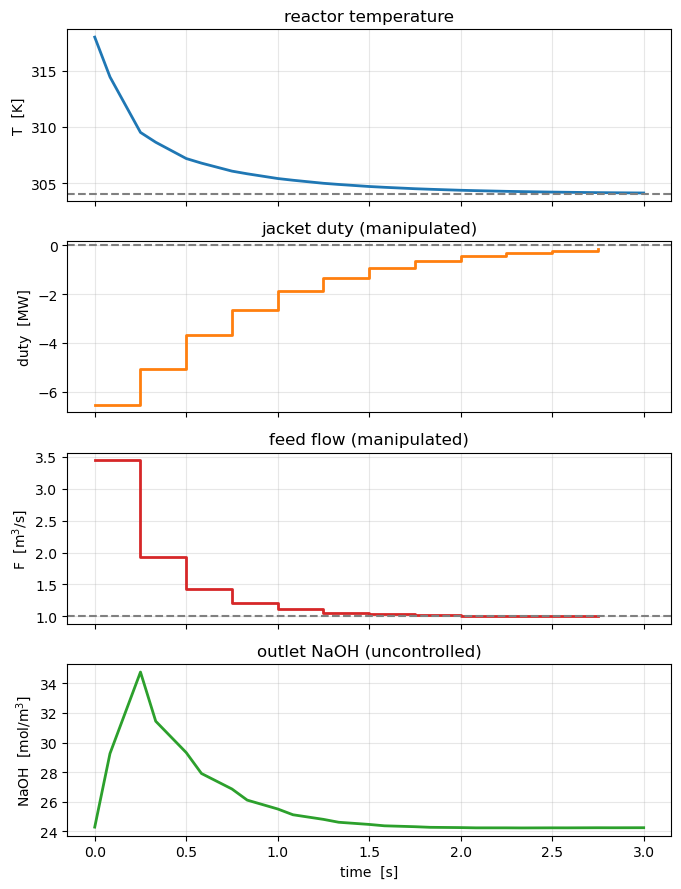

In [5]:
cv = m.fs.cstr.control_volume
duty_c, flow_c = drto.info(m).components("control")
t_all = sorted(m.fs.time)
T = [pyo.value(cv.properties_out[t].temperature) for t in t_all]
naoh = [pyo.value(cv.properties_out[t].conc_mol_comp["NaOH"]) for t in t_all]
samples = sorted(m.stage.index_set())
duty = [pyo.value(duty_c[t]) / 1e6 for t in samples]
flow = [pyo.value(flow_c[t]) for t in samples]
T_sp = pyo.value(cvs.properties_out[0.0].temperature)

fig, ax = plt.subplots(4, 1, figsize=(7, 9), sharex=True)
ax[0].plot(t_all, T, lw=2)
ax[0].axhline(T_sp, ls="--", c="0.5")
ax[0].set_ylabel("T  [K]"); ax[0].set_title("reactor temperature")
ax[1].step(samples, duty, where="post", lw=2, c="C1")
ax[1].axhline(0.0, ls="--", c="0.5")
ax[1].set_ylabel("duty  [MW]"); ax[1].set_title("jacket duty (manipulated)")
ax[2].step(samples, flow, where="post", lw=2, c="C3")
ax[2].axhline(F_IN, ls="--", c="0.5")
ax[2].set_ylabel("F  [m$^3$/s]"); ax[2].set_title("feed flow (manipulated)")
ax[3].plot(t_all, naoh, lw=2, c="C2")
ax[3].set_ylabel("NaOH  [mol/m$^3$]"); ax[3].set_xlabel("time  [s]")
ax[3].set_title("outlet NaOH (uncontrolled)")
for a in ax: a.grid(alpha=0.3)
fig.tight_layout()
plt.show()


In [6]:
seg = m.drto_ih
print(f"first duty move : {pyo.value(duty_c[0.0]):,.0f} W")
print(f"first flow move : {pyo.value(flow_c[0.0]):.3f} m3/s")
print(f"tail endpoint   : E = {pyo.value(seg.energy_holdup['Liq', 1]):,.0f} J"
      f"   (setpoint {pyo.value(m.eng_ss['Liq']):,.0f} J)")
print(f"tail feed       : T = {pyo.value(seg.properties_in_temperature[1]):.2f} K, fixed="
      f"{seg.properties_in_temperature[1].fixed}")
drto.info(m)

first duty move : -6,525,161 W
first flow move : 3.446 m3/s
tail endpoint   : E = 24,571,048 J   (setpoint 24,571,048 J)
tail feed       : T = 303.15 K, fixed=True


horizon,"fs._time (ContinuousSet, 25 points)"
states,"fs.cstr.control_volume.material_holdup (free, mol), fs.cstr.control_volume.energy_holdup (free, J)"
dynamics,"fs.cstr.control_volume.material_accumulation[t,p,j] == fs.cstr._flow_vol_inlet_ref[0.0]*fs.cstr.control_volume.properties_in[t].conc_mol_comp[j] - fs.cstr.control_volume.properties_out[t].flow_vol*fs.cstr.control_volume.properties_out[t].conc_mol_comp[j] + fs.cstr.control_volume.rate_reaction_generation[t,p,j] for t in fs.cstr.control_volume.SetProduct_OrderedSet (mol/s)"
dynamics,"fs.cstr.control_volume.energy_accumulation[t,Liq] == fs.props.dens_mol*fs.props.cp_mol*fs.cstr._flow_vol_inlet_ref[0.0]*(fs.cstr.control_volume.properties_in[t].temperature - fs.props.temperature_ref) - fs.props.dens_mol*fs.props.cp_mol*fs.cstr.control_volume.properties_out[t].flow_vol*(fs.cstr.control_volume.properties_out[t].temperature - fs.props.temperature_ref) + fs.cstr.control_volume.heat[0.0] - fs.rxn.dh_rxn[R1]*fs.cstr.control_volume.rate_reaction_extent[t,R1] for t in fs._time (W)"
controls,"fs.cstr.control_volume.heat (piecewise_constant, free, W), fs.cstr._flow_vol_inlet_ref (piecewise_constant, free, m**3/s)"
tracking stage cost,"stage[t] == ((fs.cstr.control_volume.energy_holdup[t,'Liq'] - eng_ss[Liq])/scale_E)**2 + ((fs.cstr.control_volume.heat[t] - duty_ss)/scale_Q)**2 + ((_flow_vol_inlet_ref[t] - flow_ss)/scale_F)**2 for t in sorted(fs._time)[:-1]"
initial conditions,"mat0[p,c] == fs.cstr.control_volume.material_holdup[0.0,p,c] for p in fs.props._phase_component_set, c in fs.props._phase_component_set (mol)"
initial conditions,"eng0[p] == fs.cstr.control_volume.energy_holdup[0.0,p] for p in fs.props.phase_list (J)"
steady-state targets,"mat_ss (of fs.cstr.control_volume.material_holdup, mol), eng_ss (of fs.cstr.control_volume.energy_holdup, J)"
steady-state control targets,"duty_ss (of fs.cstr.control_volume.heat, W), flow_ss (of fs.cstr._flow_vol_inlet_ref, m**3/s)"
cost_group,"drto_ih, drto_ih"


The two registries tell the whole story between them. The steady model's log
records the property blocks collapsed to their steady member for the
setpoint; the controller's log records the same blocks replicated onto the
terminal segment, the copies built with their sources' units so the
replicated balances stay dimensionally consistent on the tail.